GenAI decleration: Generative AI tools from OpenAI, Anthropic, and Google have been used to help make the code in this file.

In [1]:
import gurobipy as gp
from gurobipy import GRB
import SystemCharacteristics as data
import PlotsRestaurant
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# General model
This is the hindsight model as specified in our report

In [11]:
def hindsight_model(price, Occ_r1, Occ_r2, fixed_data, outputFlag=0):

    T = fixed_data['num_timeslots']
    T_range = range(T)
    R = [0, 1]
    M = 60
    M_hum = 100 - fixed_data['humidity_threshold']
    model = gp.Model("Restaurant_Energy_Optimization")
    
    # Initiate all decision variables
    # Temperature
    Temp_r1 = model.addVars(T, lb=-GRB.INFINITY, name="Temp_r1")
    Temp_r2 = model.addVars(T, lb=-GRB.INFINITY, name="Temp_r2")

    # Power consumption
    h_r1 = model.addVars(T, lb=0, ub=fixed_data['heating_max_power'], name="h_r1")
    h_r2 = model.addVars(T, lb=0, ub=fixed_data['heating_max_power'], name="h_r2")
    
    # ventilation status
    v = model.addVars(T, vtype=GRB.BINARY, name="v")
    
    # Humidity 
    Hum = model.addVars(T, lb=0, ub=100, name="Hum")
    
    # start-up variable
    s = model.addVars(T, vtype=GRB.BINARY, name="s")
    
    # Overrule controllers
    z_low = model.addVars(R, T, vtype=GRB.BINARY, name="z_low")
    z_high = model.addVars(R, T, vtype=GRB.BINARY, name="z_high")

    # initial conditions
    model.addConstr(Temp_r1[0] == fixed_data['initial_temperature'])
    model.addConstr(Temp_r2[0] == fixed_data['initial_temperature'])
    model.addConstr(Hum[0] == fixed_data['initial_humidity'])

    model.setObjective(
        gp.quicksum(
            (fixed_data['ventilation_power'] * v[t] + h_r1[t] + h_r2[t]) * price[t]
            for t in T_range
        ), GRB.MINIMIZE
    )

    # HUmidity Dynamics
    model.addConstrs((Hum[t] == Hum[t-1] + fixed_data['humidity_occupancy_coeff'] * (Occ_r1[t-1] + Occ_r2[t-1]) -
                    fixed_data['humidity_vent_coeff'] * v[t-1] for t in range(1,T)))
    
    # Tmperature Dynamics for both rooms
    model.addConstrs((Temp_r1[t] == Temp_r1[t-1] + fixed_data['heat_exchange_coeff'] * (Temp_r2[t-1] - Temp_r1[t-1]) +
                    fixed_data['thermal_loss_coeff'] * (fixed_data['outdoor_temperature'][t-1] - Temp_r1[t-1]) +
                    fixed_data['heating_efficiency_coeff'] * h_r1[t-1] - fixed_data['heat_vent_coeff'] * v[t-1] +
                    fixed_data['heat_occupancy_coeff'] * Occ_r1[t-1] for t in range(1,T)))
    model.addConstrs((Temp_r2[t] == Temp_r2[t-1] + fixed_data['heat_exchange_coeff'] * (Temp_r1[t-1] - Temp_r2[t-1]) +
                    fixed_data['thermal_loss_coeff'] * (fixed_data['outdoor_temperature'][t-1] - Temp_r2[t-1]) +
                    fixed_data['heating_efficiency_coeff'] * h_r2[t-1] - fixed_data['heat_vent_coeff'] * v[t-1] +
                    fixed_data['heat_occupancy_coeff'] * Occ_r2[t-1] for t in range(1,T)))
    
    # Temp-min overrule controller for both rooms
    model.addConstrs((fixed_data['temp_min_comfort_threshold'] - Temp_r1[t] <= M * z_low[0, t] for t in T_range))
    model.addConstrs((fixed_data['temp_min_comfort_threshold'] - Temp_r2[t] <= M * z_low[1, t] for t in T_range))
    model.addConstrs((z_low[0, t] >= z_low[0, t-1] - 1 + ((fixed_data['temp_OK_threshold'] - Temp_r1[t]) / M) for t in range(1,T)))
    model.addConstrs((z_low[1, t] >= z_low[1, t-1] - 1 + ((fixed_data['temp_OK_threshold'] - Temp_r2[t]) / M) for t in range(1,T)))
    model.addConstrs((h_r1[t] >= z_low[0, t] * fixed_data['heating_max_power'] for t in T_range))
    model.addConstrs((h_r2[t] >= z_low[1, t] * fixed_data['heating_max_power'] for t in T_range))
    
    # Temp-max overrule controller for both rooms
    model.addConstrs((Temp_r1[t] - fixed_data['temp_max_comfort_threshold'] <= M * z_high[0, t] for t in T_range))
    model.addConstrs((Temp_r2[t] - fixed_data['temp_max_comfort_threshold'] <= M * z_high[1, t] for t in T_range))
    model.addConstrs((h_r1[t] <= (1 - z_high[0, t]) * fixed_data['heating_max_power'] for t in T_range))
    model.addConstrs((h_r2[t] <= (1 - z_high[1, t]) * fixed_data['heating_max_power'] for t in T_range))
    
    # Humidity Overrule Controller
    model.addConstrs((Hum[t] <= fixed_data['humidity_threshold'] + M_hum * v[t]) for t in T_range)
    
    # Ventilation inertia
    model.addConstr(v[0]==s[0])
    model.addConstrs((s[t] >= v[t] - v[t-1] for t in range(1,T)))
    model.addConstrs((v[t] + v[t+1] + v[t+2] >= 3 * s[t] for t in range(T - 2)))

    model.setParam("OutputFlag", outputFlag)
    model.optimize()
    

    # Save and return results
    Temp_r1_vals = [Temp_r1[t].X for t in T_range]
    Temp_r2_vals = [Temp_r2[t].X for t in T_range]
    h_r1_vals = [h_r1[t].X for t in T_range]
    h_r2_vals = [h_r2[t].X for t in T_range]
    v_vals = [v[t].X for t in T_range]
    Hum_vals = [Hum[t].X for t in T_range]
    s_vals = [s[t].X for t in T_range]
    z_high_vals = [[z_high[r, t].X for t in T_range] for r in R]
    z_low_vals = [[z_low[r, t].X for t in T_range] for r in R]

    HVAC_results = {
        "Temp_r1": Temp_r1_vals,
        "Temp_r2": Temp_r2_vals,
        "h_r1": h_r1_vals,
        "h_r2": h_r2_vals,
        "v": v_vals,
        "s": s_vals,
        "z_high": z_high_vals,
        "z_low": z_low_vals,
        "Hum": Hum_vals,
        "price": price,
        "Occ_r1": Occ_r1,
        "Occ_r2": Occ_r2,
        "outdoor_temperature": fixed_data['outdoor_temperature'],
        "avg_cost": model.ObjVal
    }

    return HVAC_results

# 100 day simulation
Here we simulate our hindsight model for all 100 days. \
We output the average and plots for the days of your choice as specified in days_to_plot \
*Please note:  We changed the PlotsRestaurant.py file slightly to use it to display our resulyts (Not the structure, just variables ...)*

Average cost across all days: 111.39

Plotting results for day 0


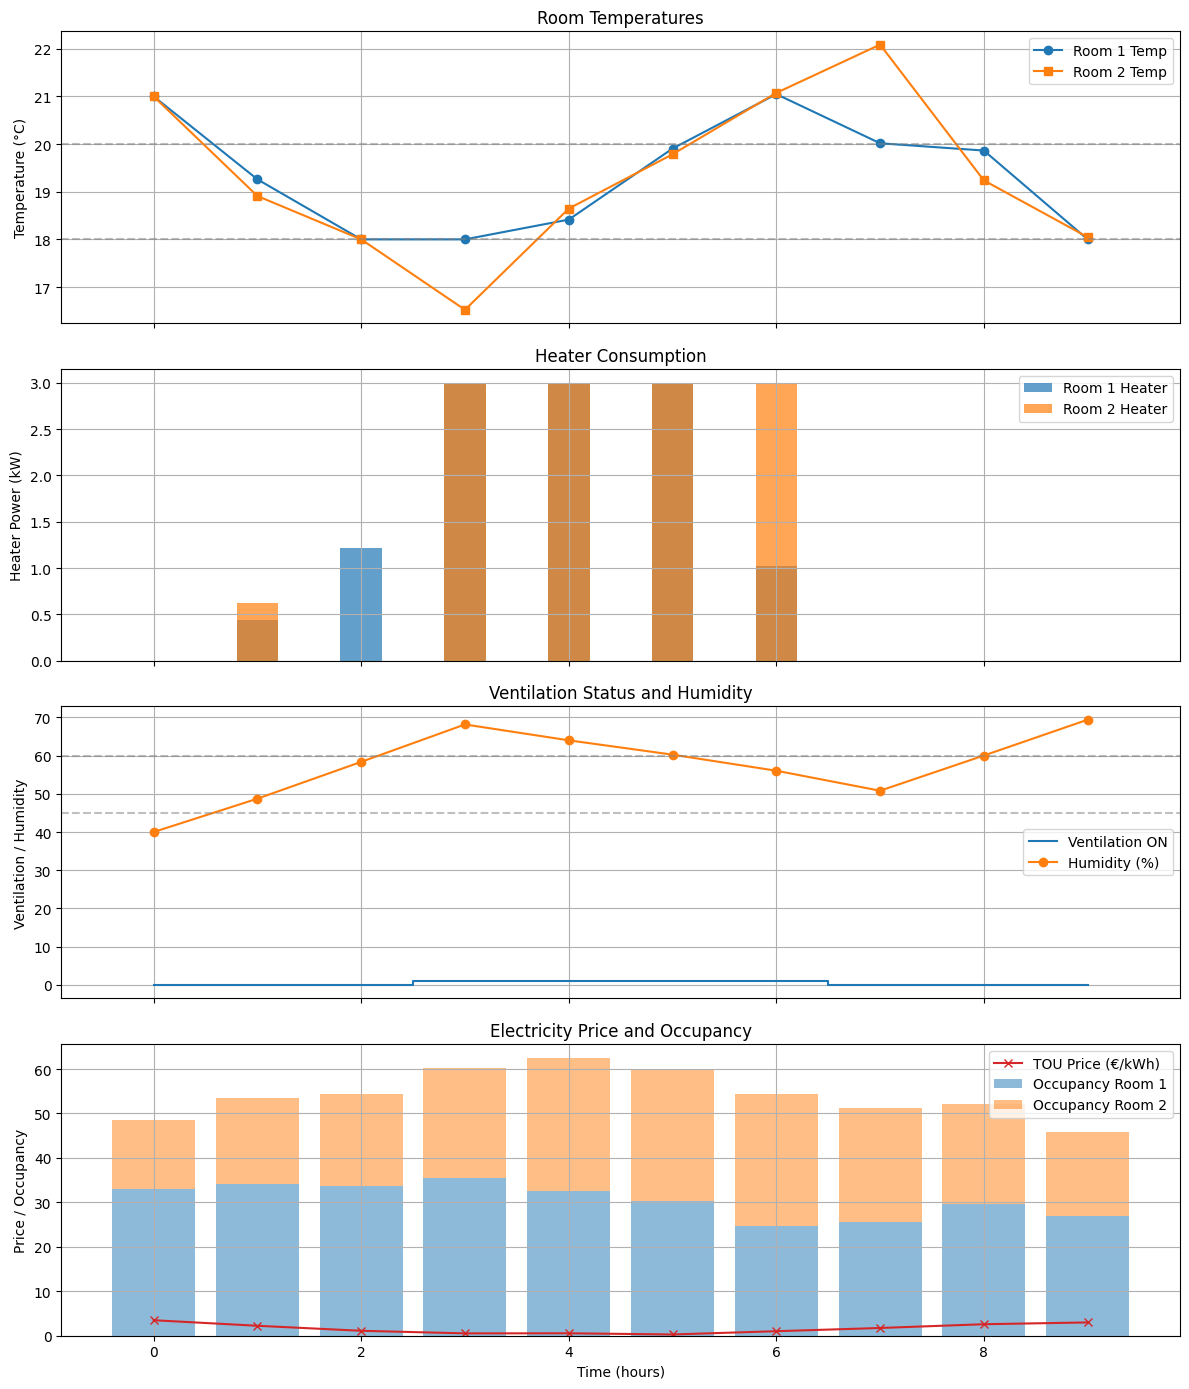


Plotting results for day 1


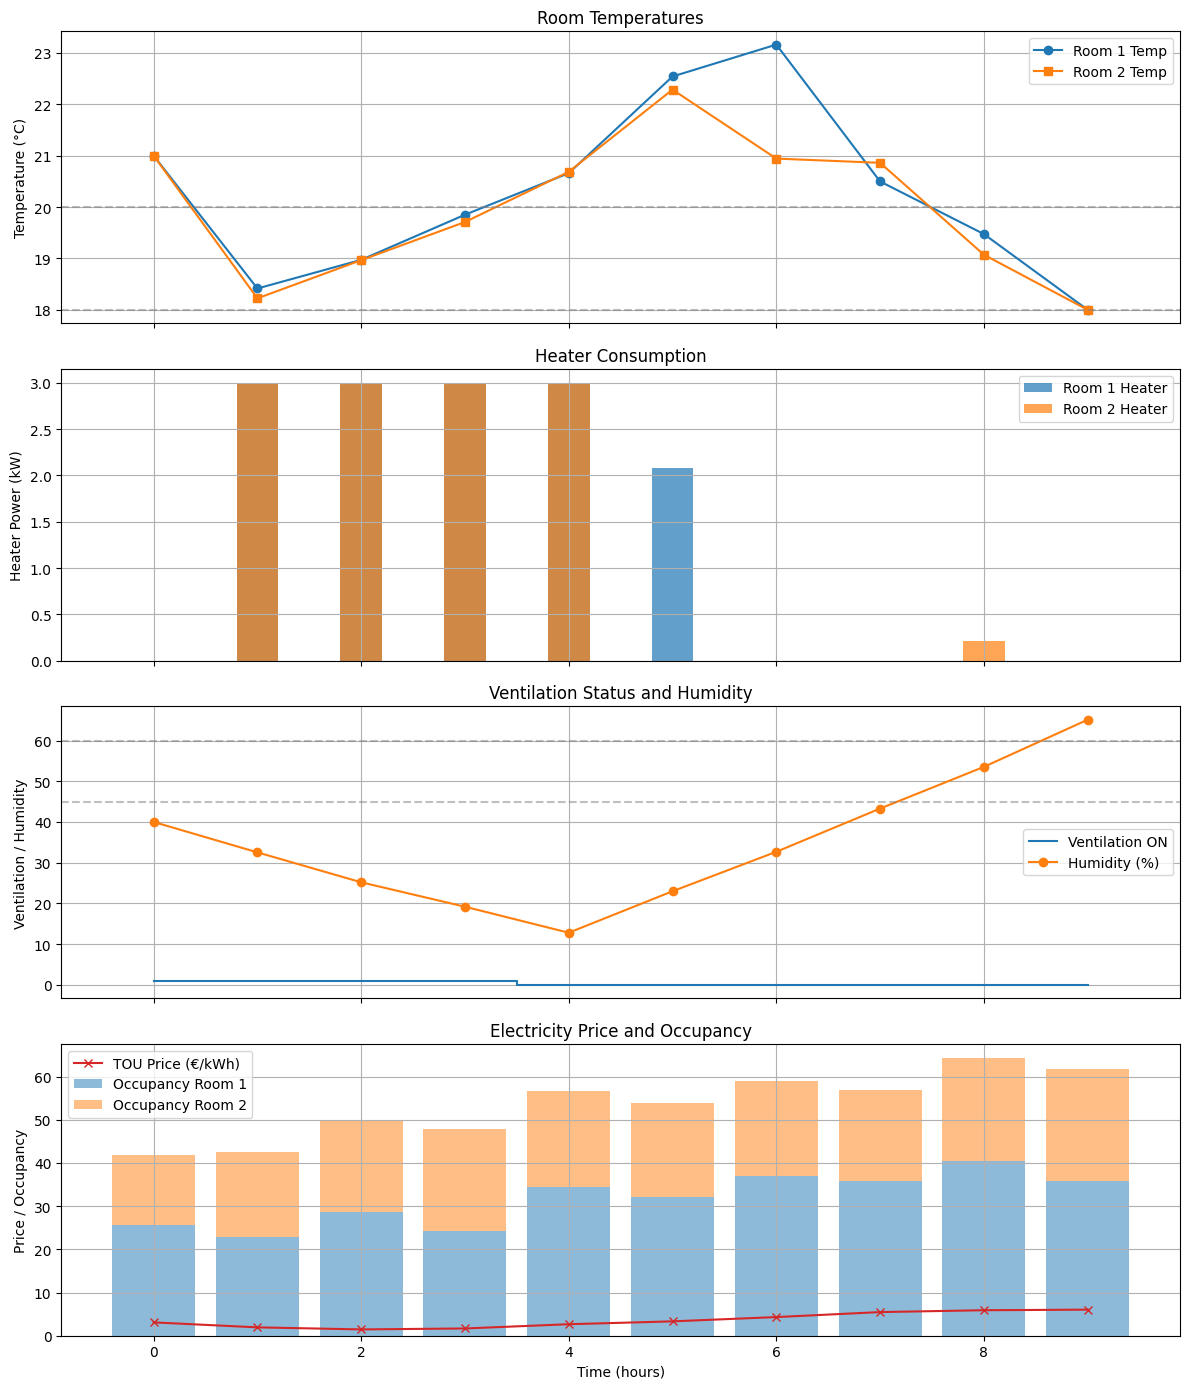

In [14]:
# Load all data
fixed_data = data.get_fixed_data()
price_data = pd.read_csv('PriceData.csv')
occ_r1_data = pd.read_csv('OccupancyRoom1.csv')
occ_r2_data = pd.read_csv('OccupancyRoom2.csv')

# SOlve MILP for all 100 days and store results
all_results = []
for day in range(price_data.shape[0]):
    price = price_data.iloc[day, :].tolist()
    Occ_r1 = occ_r1_data.iloc[day, :].tolist()
    Occ_r2 = occ_r2_data.iloc[day, :].tolist()
    
    result = hindsight_model(price, Occ_r1, Occ_r2, fixed_data)
    all_results.append(result)

# Output average cost across all days
average_cost = np.mean([res['avg_cost'] for res in all_results])
print(f"Average cost across all days: {average_cost:.2f}")

# Output results of specified days
days_to_plot = [0,1]
for day in days_to_plot:
    print(f"\nPlotting results for day {day}")
    # PlotsRestaurant.plot_HVAC_results(all_results[day])
    plot_HVAC_results(all_results[day]) # In case you want to use the Plotting function below


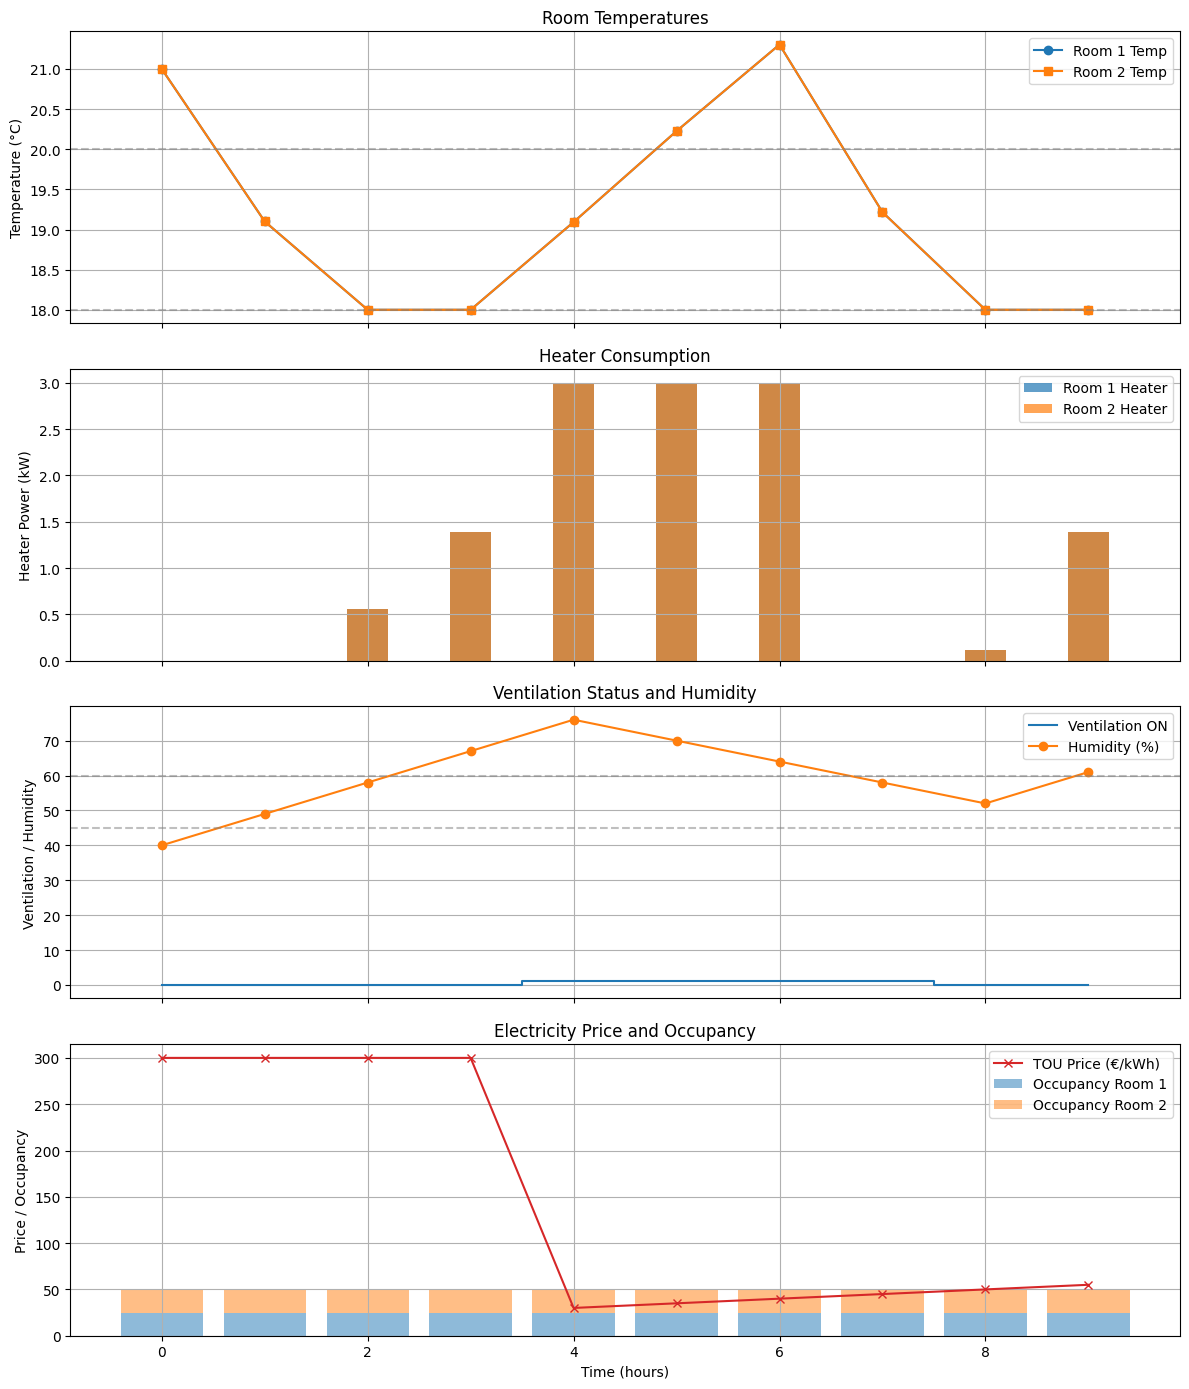

Temp_r1: [21.0, 19.1, 18.0, 18.0, 19.092705098312486, 20.226139686793722, 21.30352571811435, 19.2158782446154, 18.0, 18.0]
Temp_r2: [21.0, 19.1, 18.0, 18.0, 19.092705098312486, 20.226139686793722, 21.30352571811435, 19.2158782446154, 18.0, 18.0]
h_r1: [0.0, 0.0, 0.5527050983124829, 1.392705098312485, 3.0, 3.0, 2.9999999999999996, 0.0, 0.11300448153365394, 1.392705098312485]
h_r2: [0.0, 0.0, 0.5527050983124829, 1.392705098312485, 3.0, 3.0, 3.0, 0.0, 0.11300448153365394, 1.392705098312485]
v: [-0.0, -0.0, -0.0, -0.0, 1.0, 1.0, 1.0, 1.0, -0.0, -0.0]
s: [-0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0]
z_high: [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]]
z_low: [[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]]
Hum: [40.0, 49.0, 58.0, 67.0, 76.0, 70.0, 64.0, 58.0, 52.0, 61.0]
price: [300, 300, 300, 300, 30, 35, 40, 45, 50, 55]
Occ_r1: [25, 25, 25, 25, 25, 25, 25, 25, 25, 25]
Occ_r2: [2

In [66]:
# Self made tests
price = [300,300,300,300,30,35,40,45,50,55]
Occ_r1 = [25,25,25,25,25,25,25,25,25,25]
Occ_r2 = [25,25,25,25,25,25,25,25,25,25]

results = hinsight_model(price, Occ_r1, Occ_r2, fixed_data)
PlotsRestaurant.plot_HVAC_results(results)
# print each results line by line
for key, value in results.items():
    print(f"{key}: {value}")
    

This is our adjusted plotting function

In [13]:
def plot_HVAC_results(HVAC_results):
    import matplotlib.pyplot as plt
    
    Temp_r1 = HVAC_results['Temp_r1']
    Temp_r2 = HVAC_results['Temp_r2']
    h_r1 = HVAC_results['h_r1']
    h_r2 = HVAC_results['h_r2']
    v = HVAC_results['v']
    Hum = HVAC_results['Hum']
    price = HVAC_results['price']
    Occ_r1 = HVAC_results['Occ_r1']
    Occ_r2 = HVAC_results['Occ_r2']
    
    T = range(len(Temp_r1))
    
    fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)

    # Room Temperatures
    axes[0].plot(T, Temp_r1, label='Room 1 Temp', marker='o')
    axes[0].plot(T, Temp_r2, label='Room 2 Temp', marker='s')
    axes[0].axhline(18, color='gray', linestyle='--', alpha=0.5)
    axes[0].axhline(20, color='gray', linestyle='--', alpha=0.5)
    axes[0].set_ylabel("Temperature (°C)")
    axes[0].set_title("Room Temperatures")
    axes[0].legend()
    axes[0].grid(True)
    
    # Heater consumption
    axes[1].bar(T, h_r1, width=0.4, label='Room 1 Heater', alpha=0.7)
    axes[1].bar(T, h_r2, width=0.4, label='Room 2 Heater', alpha=0.7)
    axes[1].set_ylabel("Heater Power (kW)")
    axes[1].set_title("Heater Consumption")
    axes[1].legend()
    axes[1].grid(True)
    
    # Ventilation and Humidity
    axes[2].step(T, v, where='mid', label='Ventilation ON', color='tab:blue')
    axes[2].plot(T, Hum, label='Humidity (%)', color='tab:orange', marker='o')
    axes[2].axhline(45, color='gray', linestyle='--', alpha=0.5)
    axes[2].axhline(60, color='gray', linestyle='--', alpha=0.5)
    axes[2].set_ylabel("Ventilation / Humidity")
    axes[2].set_title("Ventilation Status and Humidity")
    axes[2].legend()
    axes[2].grid(True)
    
    # Electricity price and occupancy
    axes[3].plot(T, price, label='TOU Price (€/kWh)', color='tab:red', marker='x')
    axes[3].bar(T, Occ_r1, label='Occupancy Room 1', alpha=0.5)
    axes[3].bar(T, Occ_r2, bottom=Occ_r1, label='Occupancy Room 2', alpha=0.5)
    axes[3].set_ylabel("Price / Occupancy")
    axes[3].set_xlabel("Time (hours)")
    axes[3].set_title("Electricity Price and Occupancy")
    axes[3].legend()
    axes[3].grid(True)
    
    plt.tight_layout()
    plt.show()